# 📊 Z-Scores

This notebook demonstrates how you can calculate individual Z-scores for metrics, averages them per group, and then renormalizes that average so the final composite score has a mean of 0 and a standard deviation of 1.

‼️ **Save a copy of this notebook in your Google Drive before running**

## 📋 Step 1: Libraries and Packages

In [1]:
# Install libraries
!pip install skillcornerviz
!pip install skillcorner

# Import visualizations
from skillcornerviz.standard_plots import bar_plot as bar
from skillcornerviz.standard_plots import scatter_plot as scatter
from skillcornerviz.standard_plots import swarm_violin_plot as svp
from skillcornerviz.standard_plots import radar_plot as rad

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

  Using cached skillcornerviz-1.1.2-py3-none-any.whl.metadata (13 kB)
  Using cached adjustText-1.3.0-py3-none-any.whl.metadata (3.1 kB)
Using cached skillcornerviz-1.1.2-py3-none-any.whl (1.1 MB)
Using cached adjustText-1.3.0-py3-none-any.whl (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [skillcornerviz]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 📥 Step 2: Load Data

In [2]:
# Option 1: Fork opendata github repo and work in your local environment
# Link to repo: https://github.com/SkillCorner/opendata

In [3]:
# Option 2: Load Physical CSV file directly from Github Open Data below



# Note the change to 'raw.githubusercontent.com' and the removal of '/blob/'
url = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/aggregates/aus1league_physicalaggregates_20242025.csv"

df = pd.read_csv(url)
df.head()


,player_name,player_short_name,player_id,player_birthdate,team_name,team_id,competition_name,competition_id,season_name,season_id,...,sprint_distance_full_otip,sprint_count_full_otip,hi_distance_full_otip,hi_count_full_otip,medaccel_count_full_otip,highaccel_count_full_otip,meddecel_count_full_otip,highdecel_count_full_otip,explacceltohsr_count_full_otip,explacceltosprint_count_full_otip
0,Adam Taggart,A. Taggart,211,1993-06-02,Perth Glory Football Club,871,AUS - A-League,61,2024/2025,95,...,48.46,3.00,297.83,27.21,42.38,2.67,38.25,6.96,1.92,0.08
1,Adama Traoré,A. Traoré,218,1990-02-03,Melbourne Victory Football Club,868,AUS - A-League,61,2024/2025,95,...,69.67,4.00,315.33,25.00,37.83,2.00,25.67,4.50,1.17,0.50
2,Dino Arslanagić,D. Arslanagić,2759,1993-04-24,Macarthur FC,1804,AUS - A-League,61,2024/2025,95,...,29.12,1.25,223.25,16.88,45.12,1.75,30.75,3.50,1.25,0.00
3,Douglas Costa de Souza,Douglas Costa,2858,1990-09-14,Sydney Football Club,869,AUS - A-League,61,2024/2025,95,...,28.00,2.00,227.25,17.50,28.75,2.00,25.00,3.00,0.75,0.25
4,Douglas Costa de Souza,Douglas Costa,2858,1990-09-14,Sydney Football Club,869,AUS - A-League,61,2024/2025,95,...,1.00,0.00,170.00,16.00,26.00,0.00,21.00,2.00,0.00,0.00


## 📂 Step 3: Normalization and Filtering

The raw data in this dataset consists of cumulative season totals. To compare players fairly regardless of how many matches they started or their total playing time, we must normalize these figures into Per 90 (P90) or Per 60 (P60) metrics. The P60 metric combines TIP (Team in Possession) and OTIP (Opponent Team In Possession) numbers to get "Ball In Play" Time.

**Per 90 Minutes**

Example:
(hi_count_full_all / minutes_full_all) * 90

**Per 60 Minutes Ball in Play (BIP)**

Example:
(count_hi_full_tip+count_hi_full_otip)*60/(minutes_full_tip+minutes_full_otip)

**Matches Played**

We use a minimum treshold of 5 games when comparing players physical data

In [4]:
# Filter for players with at least 5 games
df_filtered = df[df['count_match'] >= 5].copy()

# Filter for a specific position group (e.g., Midfield)
# You can change 'Midfield' to 'Center Forward', 'Full Back', etc.
df_filtered = df_filtered[df_filtered['position_group'] == 'Midfield'].copy()

In [5]:
# Per 90 Minutes Example
df_filtered['hi_count_p90'] = (df_filtered['hi_count_full_all'] / df_filtered['minutes_full_all']) * 90
df_filtered['total_dist_p90'] = (df_filtered['total_distance_full_all'] / df_filtered['minutes_full_all']) * 90

# Per 60 Minutes Ball in Play (BIP) Example
# Combining TIP (Team in Possession) and OTIP (Opponent Team In Possession)
df_filtered['hi_count_p60_bip'] = (
    (df_filtered['hi_count_full_tip'] + df_filtered['hi_count_full_otip']) * 60 /
    (df_filtered['minutes_full_tip'] + df_filtered['minutes_full_otip'])
)

## 📊 Step 4: Metric Calculation

In [6]:
# --- 3. Z-SCORE COMPOSITE FUNCTION ---
def calculate_composite_zscores(df, metrics_group1, metrics_group2, metrics_group3,
                                name_g1='intensity', name_g2='volume', name_g3='explosivity'):
    """
    Calculates composite Z-scores for 3 groups.
    Group 1 & 2: Higher raw values are better.
    Group 3: Lower raw values (Time) are better (Inverted).
    """
    df_result = df.copy()

    # --- GROUP 1
    raw_avg_g1 = ((df[metrics_group1] - df[metrics_group1].mean()) / df[metrics_group1].std()).mean(axis=1)
    # 2. Renormalize the final average so Mean=0 and Std=1
    df_result[name_g1] = (raw_avg_g1 - raw_avg_g1.mean()) / raw_avg_g1.std()

    # --- GROUP 2
    raw_avg_g2 = ((df[metrics_group2] - df[metrics_group2].mean()) / df[metrics_group2].std()).mean(axis=1)
    # 2. Renormalize the final average so Mean=0 and Std=1
    df_result[name_g2] = (raw_avg_g2 - raw_avg_g2.mean()) / raw_avg_g2.std()

    # --- GROUP 3
    z_scores_g3 = (df[metrics_group3] - df[metrics_group3].mean()) / df[metrics_group3].std()
    # 2. Invert them (-1) so lower raw times become high positive scores
    raw_avg_g3 = (-z_scores_g3).mean(axis=1)
    # 3. Renormalize the final average so Mean=0 and Std=1
    df_result[name_g3] = (raw_avg_g3 - raw_avg_g3.mean()) / raw_avg_g3.std()

    return df_result

# --- 4. RUN CALCULATIONS ---
# Defining our groups
intensity_metrics = ['hi_count_p90', 'psv99']
volume_metrics    = ['total_dist_p90', 'hi_count_p60_bip']
explosive_metrics = ['timetohsr_top3', 'timetosprint_top3']

# Change definitions and metrics as you see fit

# Generate the scored dataframe
df_scored = calculate_composite_zscores(
    df_filtered,
    intensity_metrics,
    volume_metrics,
    explosive_metrics,
    name_g1='Intensity_Composite',
    name_g2='Volume_Composite',
    name_g3='Explosivity_Composite'
)

## 🎨 Step 5: Visualizing Intensity with a Bar Plot

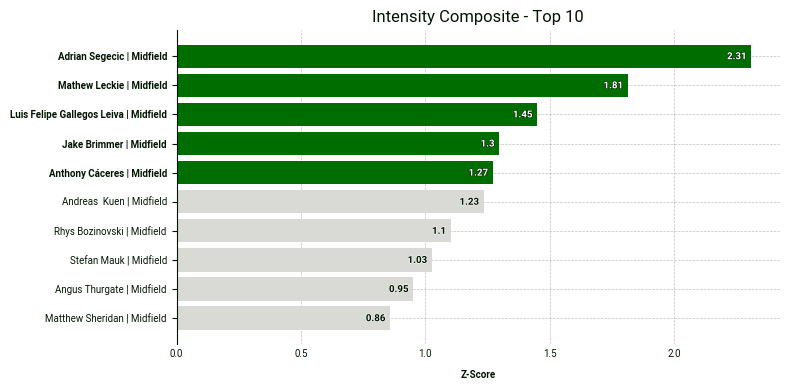

In [7]:
# 1. Sort by the composite metric and take the top 10
top_10_physical = df_scored.sort_values('Intensity_Composite', ascending=False).head(10).copy()

# 2. Create the custom plot label (Name | Position)
top_10_physical['plot_label'] = (
    top_10_physical['player_name'] + ' | ' + top_10_physical['position_group']
)

# 3. Get the IDs of the top 5 to highlight them in green
top_5_ids = top_10_physical['player_id'].head(5).tolist()

# 4. Create the bar plot
fig, ax = bar.plot_bar_chart(
    df=top_10_physical,
    metric='Intensity_Composite',
    label='Z-Score',
    primary_highlight_group=top_5_ids,   # These 5 will be green
    primary_highlight_color='#006D00',    # SkillCorner Green
    add_bar_values=True,
    data_point_id='player_id',
    data_point_label='plot_label',
    plot_title='Intensity Composite - Top 10'
)

## 🎨 Step 6: Visualizing Intensity vs Explosivity with Scatters

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


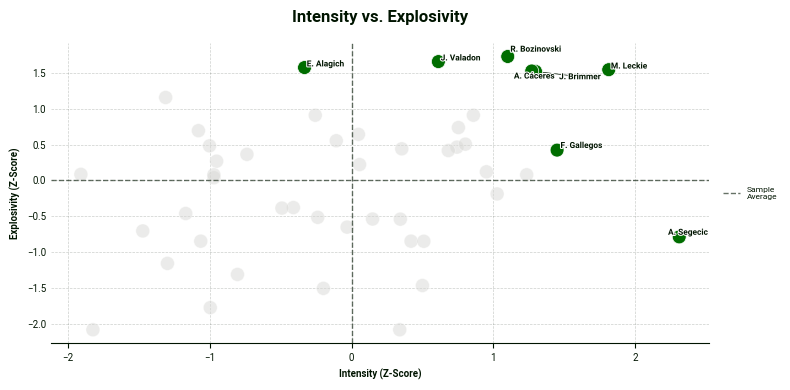

In [8]:
# --- 5. SCATTER PLOT USING df_scored ---
# Identify the Top 5 in Intensity and Explosivity to highlight
top_5_intensity_ids = df_scored.sort_values('Intensity_Composite', ascending=False).head(5)['player_id'].tolist()
top_5_explosive_ids = df_scored.sort_values('Explosivity_Composite', ascending=False).head(5)['player_id'].tolist()

highlight_players = list(set(top_5_intensity_ids + top_5_explosive_ids))

fig, ax = scatter.plot_scatter(
    df=df_scored,
    x_metric='Intensity_Composite',
    y_metric='Explosivity_Composite',
    data_point_id='player_id',
    primary_highlight_group=highlight_players,
    data_point_label='player_short_name',
    x_label='Intensity (Z-Score)',
    y_label='Explosivity (Z-Score)',
    primary_highlight_color='#006D00',
    plot_title='Intensity vs. Explosivity'
)

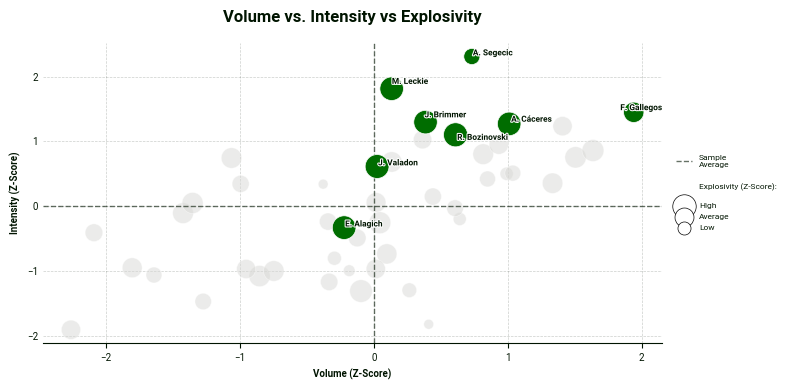

In [9]:
# --- 5. SCATTER PLOT USING df_scored ---
# Identify the Top 5 in Intensity and Explosivity to highlight and contrast them with volume using the bubble size.
top_5_intensity_ids = df_scored.sort_values('Intensity_Composite', ascending=False).head(5)['player_id'].tolist()
top_5_explosive_ids = df_scored.sort_values('Explosivity_Composite', ascending=False).head(5)['player_id'].tolist()

highlight_players = list(set(top_5_intensity_ids + top_5_explosive_ids))

fig, ax = scatter.plot_scatter(
    df=df_scored,
    x_metric='Volume_Composite',
    y_metric='Intensity_Composite',
    z_metric='Explosivity_Composite',
    data_point_id='player_id',
    primary_highlight_group=highlight_players,
    data_point_label='player_short_name',
    x_label='Volume (Z-Score)',
    y_label='Intensity (Z-Score)',
    z_label='Explosivity (Z-Score)',

    primary_highlight_color='#006D00',
    plot_title='Volume vs. Intensity vs Explosivity'
)

In [10]:
# Read and explore more about our physical data here: https://skillcorner.com/products/football/physical-data